In [213]:
import time,json,os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from sklearn.ensemble import BaggingClassifier
from common import preprocess
import seaborn as sns
from sklearn.svm import SVC
import joblib
from warnings import filterwarnings
filterwarnings("ignore") 
np.set_printoptions(suppress=True)
pd.set_option('display.float_format',lambda x : '%.4f' % x)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)
plt.style.use({'figure.figsize':(12, 4)})

In [214]:
def show_heatmap(df):
    plt.style.use({'figure.figsize':(12, 6)})
    plt.ticklabel_format(style='plain',axis='both')
    cmap = sns.cubehelix_palette(start = 1, rot = 3, gamma=0.8, as_cmap = True)
    return sns.heatmap(df, cmap = cmap, linewidths = 0.05,annot=False, fmt="g",annot_kws={"fontsize":16})
    #plt.xticks(rotation=60)
    #plt.yticks(rotation=60)

In [215]:
def get_distribution( df, metric = "EDM", degree = 9 ):
    df_test = df[[metric,'train','valid','recall', 'accuracy', 'precision', 'auc', 'f1_score']]
    df_test[metric] = ( df_test[metric] - df_test[metric].mean() ) / ( df_test[metric].max()-df_test[metric].min() ) 
    df_t = df_test.sort_values(by=metric)
    for key in [metric,'recall', 'accuracy', 'precision', 'auc', 'f1_score']:
        if not key in df_t.keys() and key != metric:
            continue
        cate = pd.qcut( df_t[key], degree, labels=False, duplicates='drop', precision=8)
        cate.fillna(-1,inplace=True)
        df_t[key] = cate
    df_dis = pd.DataFrame()
    all_data = []
    for d,df in df_t.groupby(metric):
        del df['train']
        del df['valid']
        del df[metric]
        pd_keys = df.keys()
        pd_keys.sort_values()
        for item in pd_keys:
            tmp = {}
            tmp['Distance'] = d
            tmp['Score'] = item
            jdata = json.loads(df[item].value_counts().to_json())
            json_keys = list(jdata.keys())
            json_keys.sort()
            for key in json_keys:
                value = jdata[key]
                tmp["score-%s"%key] = int(value)
            all_data.append( tmp )
    df_dis = pd.DataFrame(all_data).fillna(0)
    for i in range(len(df_t[metric].unique())):
        key = "score-%d"%i
        df_dis[key] = df_dis[key].astype(int)
    return df_dis

In [216]:
class CJAnalyse:
    
    def __init__(self, model_name):
        self.df_similarity = pd.read_csv("/data/paper/analyse/similarity.csv",index_col=0)
        self.df_model = pd.read_csv("/data/paper/analyse/%s.csv"%model_name,index_col=0)
        self.filter_useless_fields()
        
    def get_similar(self, d1, d2):
        mask = (self.df_similarity['D1'] == "%s"%d1) & (self.df_similarity['D2'] == d2)
        ret = {}
        for D in self.df_similarity.keys():
            if D in ['D1','D2']:
                continue
            ret[D] = self.df_similarity[mask].iloc[0][D]
        return ret
    
    def filter_useless_fields(self):
        df_m = self.df_model.copy( deep = True )
        del df_m['confusion_matrix']
        del df_m['roc_curve']
        del df_m['mcc']
        del df_m['log_loss']
        del df_m['fbeta_score']
        self.df_model = df_m
        
    def Merge(self):
        all_data = []
        for item in json.loads(self.df_model.to_json(orient="records")):
            tmp = item
            tmp["train"] = item["train"]
            tmp["valid"] = item["valid"]
            similar = self.get_similar(item["train"], item['valid'])
            for s in similar:
                tmp[s] = similar[s]
            all_data.append(tmp)
        return pd.DataFrame(all_data)
    
    #pearsonr,spearmanr or kendalltau
    def Correlation(self,df, kind = "pearsonr"):
        df_merged = df.copy( deep= True )
        all_data = []
        for score in self.df_model.keys():
            if score in ['model', 'train', 'valid']:
                continue
            s1 = df_merged[score]
            metric_value = {}
            metric_value['score'] = score
            metric_list = self.df_similarity.keys()
            for metric in metric_list:
                if metric in ['D1','D2']:
                    continue
                s2 = df_merged[metric]
                if kind == 'pearsonr':
                    metric_value[metric] = scipy.stats.pearsonr(s1,s2)[0]
                if kind == 'spearmanr':
                    metric_value[metric] = scipy.stats.spearmanr(s1,s2)[0]
                if kind == 'kendalltau':
                    metric_value[metric] = scipy.stats.kendalltau(s1,s2)[0]
                metric_value[metric] = abs(metric_value[metric])
            all_data.append(metric_value)

        df_all = pd.DataFrame(all_data)
        df_all.set_index("score", inplace = True, drop = True)
        return df_all #.reset_index()

In [432]:
test = CJAnalyse("rf")
df_all = test.Merge()

In [433]:
mask = (df_all['auc'] > 0.65 )# & (df_all['precision'] > 0.85 )

In [434]:
#    df_test = df[[metric,'train','valid','recall', 'accuracy', 'precision', 'auc', 'f1_score']]
df_tmp = df_all[mask]
key = "EDM"
degree = 5
cate = pd.qcut( df_tmp[key], degree, labels=False, duplicates='drop', precision=16)
#cate.fillna(-1,inplace=True)
df_tmp[key] = cate
#sns.barplot(x=key,y="f1_score",data=df_tmp)
#df_all[key].nunique()

df_test = df_tmp[[key,'recall', 'accuracy', 'precision', 'auc', 'f1_score']]
#df_test.groupby(key).mean()

<AxesSubplot:xlabel='EDM'>

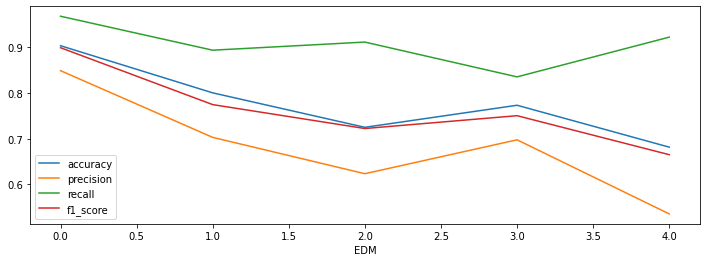

In [435]:
df_test.groupby(key)['accuracy','precision','recall','f1_score'].mean().plot()

In [317]:
df_test[df_test['EDM']==2]

,EDM,recall,accuracy,precision,auc,f1_score
25,2,1.0000,0.5393,0.5393,0.5001,0.7007
28,2,1.0000,0.7292,0.7292,0.5001,0.8434
29,2,1.0000,0.5376,0.5375,0.5002,0.6992
33,2,1.0000,0.6984,0.6229,0.6995,0.7676
101,2,0.7360,0.6624,0.6392,0.6629,0.6842
...,...,...,...,...,...,...
985,2,0.9841,0.5421,0.5415,0.5045,0.6986
987,2,0.9979,0.8617,0.8627,0.5140,0.9254
989,2,0.9854,0.5432,0.5412,0.5075,0.6987
990,2,0.9980,0.7321,0.7316,0.5099,0.8443
